# DS 423 SA — Machine Learning with Large Datasets
## Group 11 — Face Mask Detection (Object Detection)
**Duy Tan University, Da Nang**

| Member | Student ID | Role |
|---|---|---|
| Tran Van Truong | 28211452515 | Data & Analysis Lead |
| Nguyen Nhu Nguyen | 28211403542 | Modeling & Evaluation Lead |

This notebook runs **on a local personal machine**: Windows 11, VS Code + Jupyter,
GPU NVIDIA RTX 3050 Laptop (4GB VRAM). Parts 1–5 (data collection/cleaning/EDA/feature
engineering/Dataset) were completed by Tran Van Truong on Kaggle, then adjusted
for local execution. Parts 6–10 (model building, training, evaluation) were completed
by Nguyen Nhu Nguyen on the local machine, using **YOLOv8s (Ultralytics)**.

**Installation requirements (run once, uncomment `#`):**
```
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install albumentations opencv-python pandas numpy matplotlib seaborn scikit-learn pyyaml
%pip install ultralytics
```
If your machine does not have a compatible NVIDIA/CUDA GPU, install the CPU version: `%pip install torch torchvision`
(YOLOv8s can still run on CPU, but training will be much slower).

**Expected directory structure (place next to this .ipynb file):**
```
data/face-mask-detection/images/*.png
data/face-mask-detection/annotations/*.xml
data/face-mask-yolo/          <- dataset converted to YOLO format (auto-generated in Part 6)
outputs/models/               <- model checkpoints (.pt) will be saved here
outputs/charts/               <- charts for report/slides will be saved here
outputs/yolov8s_facemask_final/  <- training logs/results generated by Ultralytics
```

In [1]:
# =====================================================================
# FACE MASK DETECTION - DATA PIPELINE
# Dataset: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
# Steps: 1) Load  2) Clean/Preprocess  3) EDA  4) Feature Engineering
# =====================================================================

import os
import glob
from pathlib import Path
from collections import Counter
import random
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# ---------------------------------------------------------------------
# 1. DATA COLLECTION & LOADING  (adjusted for local machine - Windows 11)
# ---------------------------------------------------------------------
# How to download the dataset to your local machine:
#   Option 1 (manual): download the zip at https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
#                      then extract it into the folder "data/face-mask-detection" next to this notebook.
#   Option 2 (Kaggle API): %pip install kaggle
#                          kaggle datasets download -d andrewmvd/face-mask-detection -p data --unzip

def find_project_root():
    """Find the folder that contains data/face-mask-detection.

    Jupyter/VS Code sometimes starts kernels from a different working
    directory; relying only on os.getcwd() can silently point the notebook
    at the wrong data/output folders.
    """
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path(r"C:/Users/FPTSHOP/Desktop/Face_Mask_Detection"),
    ]
    for candidate in candidates:
        if (candidate / "data" / "face-mask-detection").is_dir():
            return candidate
    return Path.cwd()


PROJECT_ROOT = str(find_project_root())
dataset_path = os.path.join(PROJECT_ROOT, "data", "face-mask-detection")
images_path = os.path.join(dataset_path, "images")
annotations_path = os.path.join(dataset_path, "annotations")

# Output directory (trained model + charts for report/slides)
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
CHART_DIR = os.path.join(OUTPUT_DIR, "charts")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

# Safety check so you get a clear error instead of a confusing crash
# later if the dataset isn't placed under this exact folder.
if not os.path.isdir(dataset_path):
    raise FileNotFoundError(
        f"Dataset path not found: {dataset_path}\n"
        "-> Download the 'Face Mask Detection' dataset (andrewmvd) from Kaggle and extract "
        "it into the correct folder 'data/face-mask-detection' next to this notebook file."
    )

def parse_xml(xml_file):
    """Parse a PASCAL VOC XML annotation file into a list of box dicts. """
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        filename = root.find("filename").text
        image_width = int(root.find("size").find("width").text)
        image_height = int(root.find("size").find("height").text)

        objects = []
        for obj in root.findall("object"):
            label = obj.find("name").text
            bndbox = obj.find("bndbox")
            xmin = int(bndbox.find("xmin").text)
            ymin = int(bndbox.find("ymin").text)
            xmax = int(bndbox.find("xmax").text)
            ymax = int(bndbox.find("ymax").text)

            objects.append({
                "filename": filename,
                "width": image_width,
                "height": image_height,
                "label": label,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax
            })
        return objects
    except Exception as e:
        print(f"[WARN] Skipping unreadable annotation file: {xml_file} ({e})")
        return []

# Read all XML annotation files into a single DataFrame
annotations = glob.glob(os.path.join(annotations_path, "*.xml"))
if len(annotations) == 0:
    raise FileNotFoundError(f"No .xml files found in {annotations_path}")

all_objects = []
for xml_file in annotations:
    all_objects.extend(parse_xml(xml_file))

df = pd.DataFrame(all_objects)
print(f"Total bounding boxes found: {len(df)}")
print(f"Total unique images: {df['filename'].nunique()}")
df.head()

Total bounding boxes found: 4072
Total unique images: 853


,filename,width,height,label,xmin,ymin,xmax,ymax
0,maksssksksss0.png,512,366,without_mask,79,105,109,142
1,maksssksksss0.png,512,366,with_mask,185,100,226,144
2,maksssksksss0.png,512,366,without_mask,325,90,360,141
3,maksssksksss1.png,400,156,with_mask,321,34,354,69
4,maksssksksss1.png,400,156,with_mask,224,38,261,73


In [3]:
# ---------------------------------------------------------------------
# 2. DATA CLEANING & PREPROCESSING
# ---------------------------------------------------------------------

# 2.1 Missing values
print("\nMissing values per column:")
print(df.isnull().sum())
df = df.dropna(subset=["filename", "label", "xmin", "ymin", "xmax", "ymax"]).reset_index(drop=True)

# 2.2 Clamp boxes to image bounds, then drop truly invalid boxes.
# Some original XML files contain xmax/ymax one pixel outside the image
# (e.g. xmax=401 for width=400). Leaving those values uncorrected can
# break bbox transforms or make the model learn noisy targets.
for col in ["xmin", "ymin", "xmax", "ymax", "width", "height"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["xmin", "ymin", "xmax", "ymax", "width", "height"]).reset_index(drop=True)

out_of_bounds = (
    (df["xmin"] < 0) | (df["ymin"] < 0) |
    (df["xmax"] > df["width"]) | (df["ymax"] > df["height"])
)
print(f"\nOut-of-bound boxes corrected: {int(out_of_bounds.sum())}")
df["xmin"] = df["xmin"].clip(lower=0)
df["ymin"] = df["ymin"].clip(lower=0)
df["xmax"] = df[["xmax", "width"]].min(axis=1)
df["ymax"] = df[["ymax", "height"]].min(axis=1)

invalid_boxes = df[(df["xmin"] >= df["xmax"]) | (df["ymin"] >= df["ymax"])]
print(f"Invalid bounding boxes after clipping: {len(invalid_boxes)}")
if len(invalid_boxes) > 0:
    df = df[(df["xmin"] < df["xmax"]) & (df["ymin"] < df["ymax"])].reset_index(drop=True)
    print("Dropped invalid boxes.")

df[["xmin", "ymin", "xmax", "ymax", "width", "height"]] = df[
    ["xmin", "ymin", "xmax", "ymax", "width", "height"]
].astype(np.int64)

# 2.3 Label encoding (background implicitly reserved as class 0)
label_map = {
    "with_mask": 1,
    "without_mask": 2,
    "mask_weared_incorrect": 3
}
df['label_id'] = df['label'].map(label_map)


# producing NaN -> crash later when cast to int64.
unmapped = df[df['label_id'].isna()]
if len(unmapped) > 0:
    print(f"\n[WARN] {len(unmapped)} rows have an unmapped label and will be dropped:")
    print(unmapped['label'].value_counts())
    df = df.dropna(subset=['label_id']).reset_index(drop=True)
df['label_id'] = df['label_id'].astype(np.int64)

# 2.4 Verify physical image files exist, and DROP rows for missing ones
df['image_path'] = df['filename'].apply(lambda x: os.path.join(images_path, x))
missing_mask = ~df['image_path'].apply(os.path.exists)
missing_images = df[missing_mask]
print(f"\nRecords with missing physical image file: {len(missing_images)}")
if len(missing_images) > 0:
    df = df[~missing_mask].reset_index(drop=True)
    print("Dropped rows with missing image files.")

print("\nCleaned data preview:")
print(df.head())


Missing values per column:
filename    0
width       0
height      0
label       0
xmin        0
ymin        0
xmax        0
ymax        0
dtype: int64

Out-of-bound boxes corrected: 12
Invalid bounding boxes after clipping: 0

Records with missing physical image file: 0

Cleaned data preview:
            filename  width  height         label  xmin  ymin  xmax  ymax  \
0  maksssksksss0.png    512     366  without_mask    79   105   109   142   
1  maksssksksss0.png    512     366     with_mask   185   100   226   144   
2  maksssksksss0.png    512     366  without_mask   325    90   360   141   
3  maksssksksss1.png    400     156     with_mask   321    34   354    69   
4  maksssksksss1.png    400     156     with_mask   224    38   261    73   

   label_id                                         image_path  
0         2  c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\d...  
1         1  c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\d...  
2         2  c:\Users\FPTSHOP\Desktop\Face_Mas


Class balance:
  with_mask: 3232 (79.4%)
  without_mask: 717 (17.6%)
  mask_weared_incorrect: 123 (3.0%)


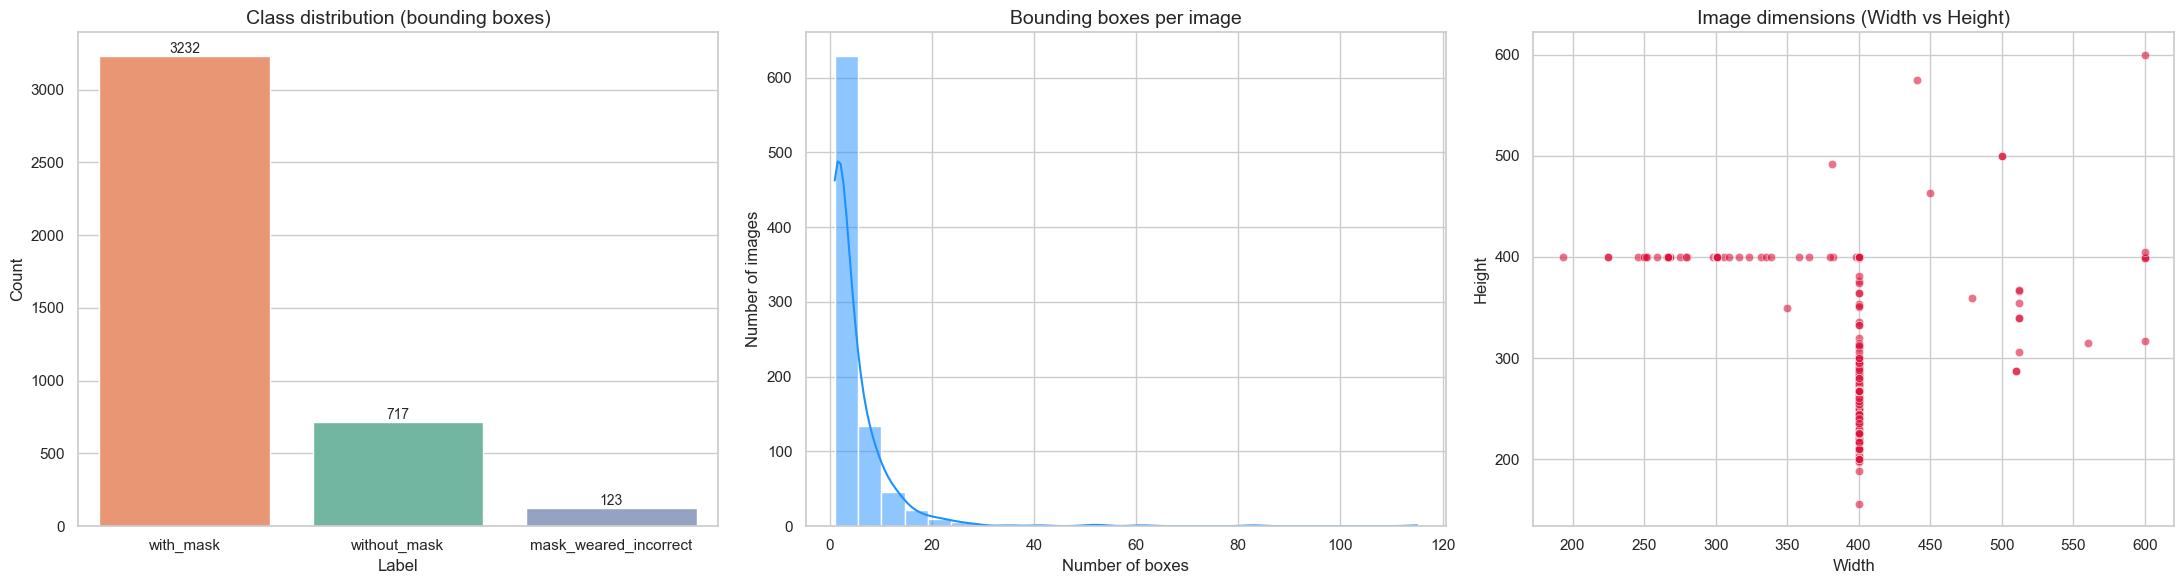

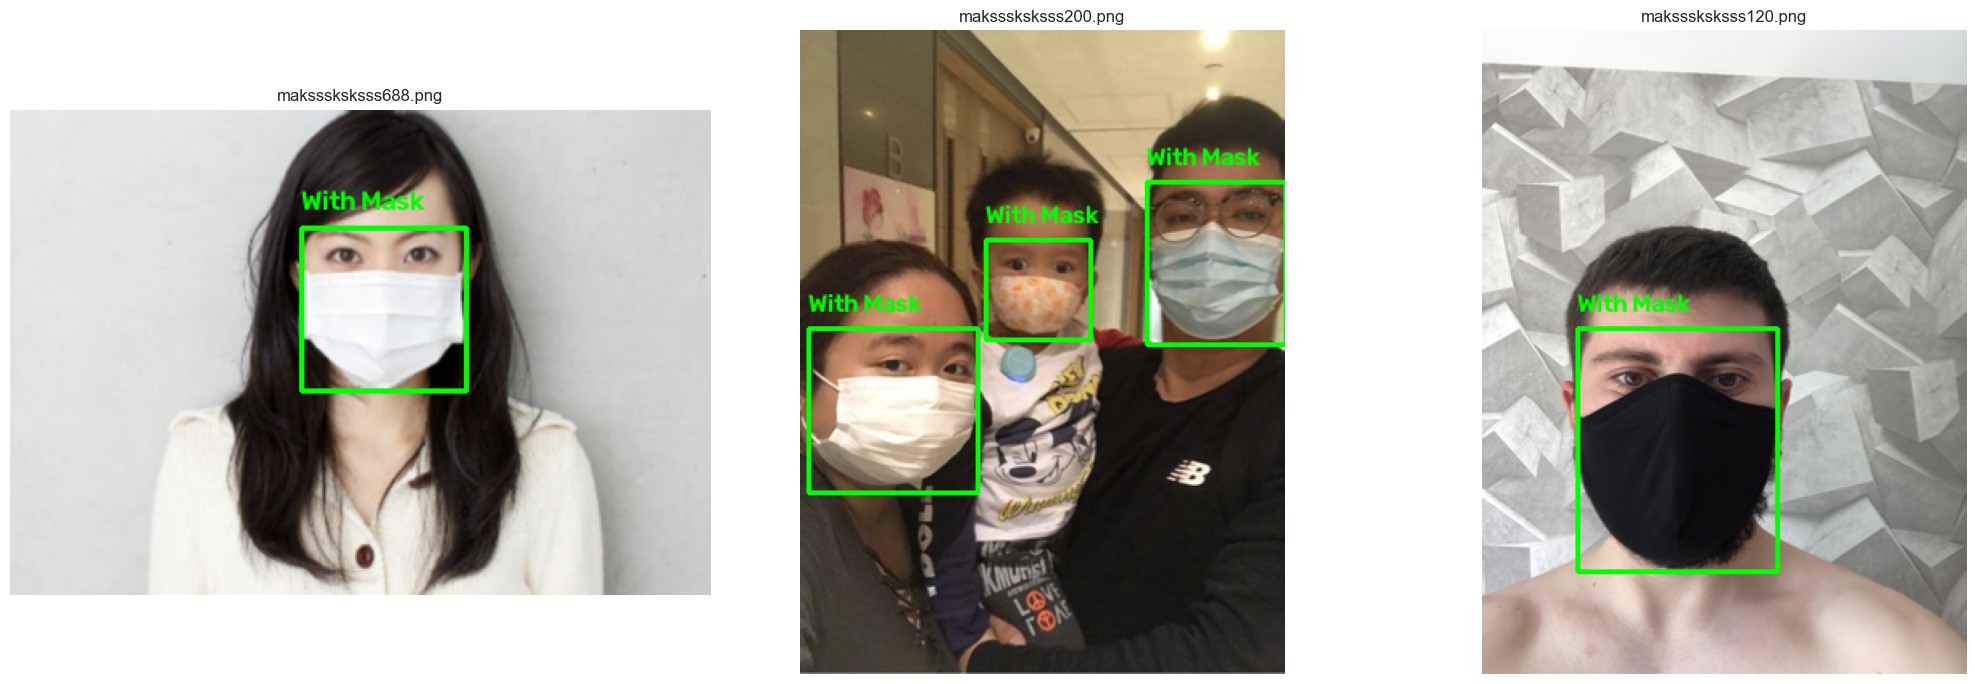

In [4]:
# ---------------------------------------------------------------------
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------------------

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Chart 1: Class distribution
order = df['label'].value_counts().index
sns.countplot(data=df, x='label', hue='label', order=order, palette='Set2',
              legend=False, ax=axes[0])
axes[0].set_title("Class distribution (bounding boxes)", fontsize=14)
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', xytext=(0, 5),
                      textcoords='offset points', fontsize=10)

# Explicit class imbalance check (useful before training a detector)
class_counts = df['label'].value_counts()
class_pct = (class_counts / class_counts.sum() * 100).round(1)
print("\nClass balance:")
for lbl, cnt in class_counts.items():
    print(f"  {lbl}: {cnt} ({class_pct[lbl]}%)")

# Chart 2: Boxes per image
boxes_per_image = df.groupby('filename').size()
sns.histplot(boxes_per_image, bins=25, kde=True, ax=axes[1], color='dodgerblue')
axes[1].set_title("Bounding boxes per image", fontsize=14)
axes[1].set_xlabel("Number of boxes")
axes[1].set_ylabel("Number of images")

# Chart 3: Image size distribution
unique_images = df.drop_duplicates(subset=['filename'])
sns.scatterplot(data=unique_images, x='width', y='height', alpha=0.6,
                 ax=axes[2], color='crimson')
axes[2].set_title("Image dimensions (Width vs Height)", fontsize=14)
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "eda_overview.png"), dpi=150)
plt.show()

def plot_random_samples(df, num_samples=3, seed=SEED):
    rng = random.Random(seed)
    unique_files = df['filename'].unique()
    n = min(num_samples, len(unique_files))
    sampled_files = rng.sample(list(unique_files), n)

    colors = {1: (0, 255, 0), 2: (255, 0, 0), 3: (255, 165, 0)}
    label_text = {1: "With Mask", 2: "Without Mask", 3: "Incorrect"}

    fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
    if n == 1:
        axes = [axes]

    for i, file in enumerate(sampled_files):
        img_data = df[df['filename'] == file]
        img_path = img_data['image_path'].iloc[0]

        image = cv2.imread(img_path)
        if image is None:
            axes[i].set_title(f"Could not read: {file}")
            axes[i].axis('off')
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        for _, row in img_data.iterrows():
            xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
            lbl_id = row['label_id']
            cv2.rectangle(image, (xmin, ymin), (xmax, ymax), colors[lbl_id], 2)
            cv2.putText(image, label_text[lbl_id], (xmin, max(ymin - 10, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[lbl_id], 2)

        axes[i].imshow(image)
        axes[i].set_title(file)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(CHART_DIR, "eda_sample_images.png"), dpi=150)
    plt.show()

plot_random_samples(df, num_samples=3)


Engineered feature summary:
         box_width   box_height       box_area  aspect_ratio   area_ratio
count  4072.000000  4072.000000    4072.000000   4072.000000  4072.000000
mean     31.146120    35.004912    1977.970530      0.914255     0.017062
std      27.960328    32.635004    4693.437916      0.178088     0.033748
min       1.000000     2.000000       2.000000      0.300000     0.000000
25%      14.000000    16.000000     225.000000      0.818000     0.002200
50%      22.000000    24.000000     528.000000      0.909000     0.005100
75%      36.000000    40.000000    1369.000000      1.000000     0.013525
max     317.000000   340.000000  106829.000000      2.510000     0.427300


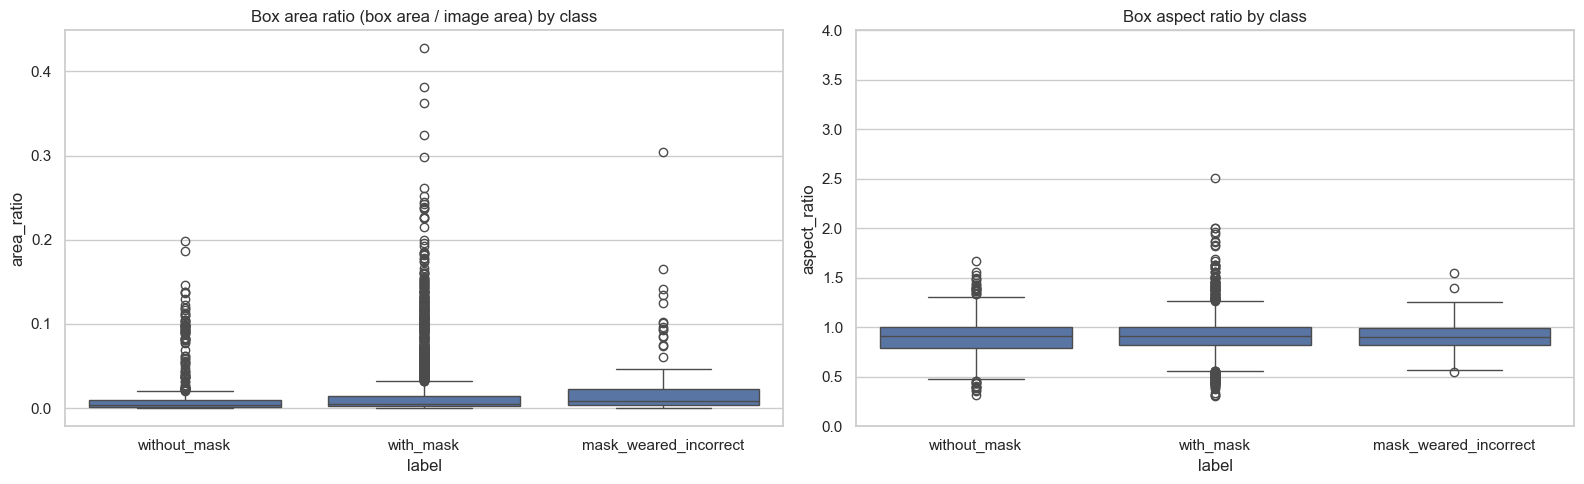

In [5]:
# ---------------------------------------------------------------------
# 4. FEATURE ENGINEERING / DATA PREPARATION
# ---------------------------------------------------------------------

# Per-box geometric features - useful for anchor-size design and
# for spotting annotation outliers (e.g. near-zero-area boxes).
df['box_width'] = df['xmax'] - df['xmin']
df['box_height'] = df['ymax'] - df['ymin']
df['box_area'] = df['box_width'] * df['box_height']
df['aspect_ratio'] = (df['box_width'] / df['box_height']).round(3)
df['area_ratio'] = (df['box_area'] / (df['width'] * df['height'])).round(4)

# Per-image feature: how many faces/boxes it contains
boxes_count = df.groupby('filename')['filename'].transform('count')
df['boxes_in_image'] = boxes_count

print("\nEngineered feature summary:")
print(df[['box_width', 'box_height', 'box_area', 'aspect_ratio', 'area_ratio']].describe())

# Visualize engineered features by class - helps decide anchor scales
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x='label', y='area_ratio', ax=axes[0])
axes[0].set_title("Box area ratio (box area / image area) by class")
sns.boxplot(data=df, x='label', y='aspect_ratio', ax=axes[1])
axes[1].set_ylim(0, 4)  # clip extreme outliers for readability
axes[1].set_title("Box aspect ratio by class")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "feature_engineering.png"), dpi=150)
plt.show()

In [6]:
# ---------------------------------------------------------------------
# 5. TRAIN/VAL SPLIT (prepare shared data for Parts 6-10)
#    Note: conversion to model-specific training format (YOLOv8s) is
#    done in Part 6 - Model Selection & Building,
#    because the data format depends on the selected model.
# ---------------------------------------------------------------------

import torch
from sklearn.model_selection import train_test_split

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

image_groups = df.groupby('filename')
grouped_data = []
for filename, group in image_groups:
    grouped_data.append({
        'filename': filename,
        'image_path': group['image_path'].iloc[0],
        'width': int(group['width'].iloc[0]),
        'height': int(group['height'].iloc[0]),
        'boxes': group[['xmin', 'ymin', 'xmax', 'ymax']].values.astype(np.float32),
        'labels': group['label_id'].values.astype(np.int64)
    })

# Stratify by majority class per image so the validation set remains
# representative, especially for the minority class mask_weared_incorrect.
stratify_labels = [Counter(item["labels"]).most_common(1)[0][0] for item in grouped_data]
try:
    train_data, val_data = train_test_split(
        grouped_data, test_size=0.2, random_state=SEED, stratify=stratify_labels
    )
except ValueError:
    train_data, val_data = train_test_split(grouped_data, test_size=0.2, random_state=SEED)

print(f"\nTrain images: {len(train_data)}")
print(f"Val images: {len(val_data)}")

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")



Train images: 682
Val images: 171
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


---
## Part 6–10: Model Building, Training & Evaluation
**By: Nguyen Nhu Nguyen (Modeling & Evaluation Lead)**

Selected model: **YOLOv8s (Ultralytics)**, pretrained on COCO.

**Reasons for choosing YOLOv8s for NVIDIA RTX 3050 Laptop GPU (4GB VRAM):**
- YOLOv8s is the "small" variant of the YOLOv8 family, offering a good balance
  between speed and accuracy; much lighter than YOLOv8m/l/x, suitable for limited VRAM.
- 1-stage detector architecture (unlike Faster R-CNN 2-stage) delivers near-real-time
  inference speed, fitting for public health surveillance scenarios that require
  continuous image/camera-stream processing.
- Supports transfer learning from pretrained COCO weights, enabling faster convergence
  and better results even with the relatively small Face Mask Detection dataset (853 images).
- The `ultralytics` library includes built-in augmentation, AMP (mixed precision),
  mAP/Precision/Recall computation, and training logging, making the pipeline
  compact and less error-prone when running on a modest personal machine.

In [7]:
# =====================================================================
# 6. MODEL SELECTION & BUILDING
# Model: YOLOv8s (Ultralytics), pretrained on COCO -> transfer learning
# =====================================================================

%pip install -q ultralytics pyyaml

import shutil
import time
import yaml
import torchvision
from ultralytics import YOLO

device_str = '0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device_str}" + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))

# ---------------------------------------------------------------------
# 6.1 Convert data to YOLO format
#     YOLO requires: images/{train,val}/*.png + labels/{train,val}/*.txt
#     each line: <class_id> <x_center> <y_center> <width> <height>,
#     coordinates NORMALIZED [0,1] relative to original image size, class_id 0-based.
# ---------------------------------------------------------------------
YOLO_DATASET_DIR = os.path.join(PROJECT_ROOT, "data", "face-mask-yolo")
yolo_images_train = os.path.join(YOLO_DATASET_DIR, "images", "train")
yolo_images_val = os.path.join(YOLO_DATASET_DIR, "images", "val")
yolo_labels_train = os.path.join(YOLO_DATASET_DIR, "labels", "train")
yolo_labels_val = os.path.join(YOLO_DATASET_DIR, "labels", "val")
for d in [yolo_images_train, yolo_images_val, yolo_labels_train, yolo_labels_val]:
    os.makedirs(d, exist_ok=True)

# label_map (created in Part 2): {"with_mask": 1, "without_mask": 2, "mask_weared_incorrect": 3}
# YOLO requires 0-based class_id -> sort by original id then subtract 1 when writing .txt files
YOLO_CLASS_NAMES = [name for name, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
print(f"YOLO classes (id 0..{len(YOLO_CLASS_NAMES) - 1}): {YOLO_CLASS_NAMES}")


def convert_split_to_yolo(data_list, images_out_dir, labels_out_dir):
    """Copy images + generate YOLO-format .txt annotation files for one split (train/val)."""
    n_boxes = 0
    for item in data_list:
        filename = item['filename']
        src_path = item['image_path']
        dst_path = os.path.join(images_out_dir, filename)
        if not os.path.exists(dst_path):
            shutil.copyfile(src_path, dst_path)

        img_w, img_h = item['width'], item['height']
        lines = []
        for (x1, y1, x2, y2), label_id in zip(item['boxes'], item['labels']):
            class_id = int(label_id) - 1  # YOLO id: 0-based
            x_center = min(max(((x1 + x2) / 2.0) / img_w, 0.0), 1.0)
            y_center = min(max(((y1 + y2) / 2.0) / img_h, 0.0), 1.0)
            box_w = min(max((x2 - x1) / img_w, 0.0), 1.0)
            box_h = min(max((y2 - y1) / img_h, 0.0), 1.0)
            lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}")
            n_boxes += 1

        label_path = os.path.join(labels_out_dir, os.path.splitext(filename)[0] + ".txt")
        with open(label_path, "w") as f:
            f.write("\n".join(lines))
    return n_boxes


n_train_boxes = convert_split_to_yolo(train_data, yolo_images_train, yolo_labels_train)
n_val_boxes = convert_split_to_yolo(val_data, yolo_images_val, yolo_labels_val)
print("\nConverted to YOLO format:")
print(f"  - Train: {len(train_data)} images, {n_train_boxes} bounding boxes")
print(f"  - Val  : {len(val_data)} images, {n_val_boxes} bounding boxes")

# ---------------------------------------------------------------------
# 6.2 Dataset configuration file (data.yaml) for Ultralytics YOLO
# ---------------------------------------------------------------------
data_yaml = {
    "path": YOLO_DATASET_DIR,
    "train": "images/train",
    "val": "images/val",
    "nc": len(YOLO_CLASS_NAMES),
    "names": YOLO_CLASS_NAMES,
}
DATA_YAML_PATH = os.path.join(YOLO_DATASET_DIR, "data.yaml")
with open(DATA_YAML_PATH, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)
print(f"\nSaved dataset configuration file: {DATA_YAML_PATH}")
print(yaml.dump(data_yaml, default_flow_style=False, allow_unicode=True))

# ---------------------------------------------------------------------
# 6.3 Initialize YOLOv8s model (pretrained on COCO -> transfer learning)
#     The first run will automatically download the yolov8s.pt weights (~22MB) from
#     Ultralytics (requires internet); subsequent runs use the locally cached version.
# ---------------------------------------------------------------------
def build_yolo_model(weights="yolov8s.pt"):
    return YOLO(weights)


model = build_yolo_model("yolov8s.pt")
n_params = sum(p.numel() for p in model.model.parameters())
print(f"\nModel: YOLOv8s | Parameters: {n_params:,} | Classes: {len(YOLO_CLASS_NAMES)} (+ background handled internally by YOLO)")



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Using device: 0 (NVIDIA GeForce RTX 3050 Laptop GPU)
YOLO classes (id 0..2): ['with_mask', 'without_mask', 'mask_weared_incorrect']

Converted to YOLO format:
  - Train: 682 images, 3309 bounding boxes
  - Val  : 171 images, 763 bounding boxes

Saved dataset configuration file: c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\data.yaml
names:
- with_mask
- without_mask
- mask_weared_incorrect
nc: 3
path: c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo
train: images/train
val: images/val



100%|██████████| 21.5M/21.5M [00:01<00:00, 16.8MB/s]
c:\Program Files\Python310\lib\site-packages\ultralytics\nn\tasks.py:634: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  


Model: YOLOv8s | Parameters: 11,166,560 | Classes: 3 (+ background handled internally by YOLO)


In [8]:
# =====================================================================
# 7. TRAINING SETUP
# Ultralytics automatically enables Automatic Mixed Precision (AMP=True) when a CUDA GPU is available
# -> reduces VRAM usage, important for 4GB GPUs like the RTX 3050 Laptop.
# =====================================================================
IMG_SIZE = 416      # reduced from default 640 -> suitable for 4GB VRAM
BATCH_SIZE = 8      # YOLOv8s is lighter than Faster R-CNN so batch size can be increased
WORKERS = 0         # avoid DataLoader multiprocessing pickle errors on Windows

COMMON_TRAIN_KWARGS = dict(
    data=DATA_YAML_PATH,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    device=device_str,
    seed=SEED,
    amp=True,
    verbose=False,
    project=OUTPUT_DIR,
    exist_ok=True,
)

print("Common training configuration:")
for k, v in COMMON_TRAIN_KWARGS.items():
    print(f"  - {k}: {v}")


Common training configuration:
  - data: c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\data.yaml
  - imgsz: 416
  - batch: 8
  - workers: 0
  - device: 0
  - seed: 42
  - amp: True
  - verbose: False
  - project: c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs
  - exist_ok: True


In [9]:
# ---------------------------------------------------------------------
# 7.1 HYPERPARAMETER TUNING
# Small search (a few epochs) over the initial learning rate (lr0) to select
# the best configuration before full training - suitable for the time/resource
# constraints of a personal machine.
# ---------------------------------------------------------------------
SEARCH_EPOCHS = 3
lr_candidates = [0.01, 0.005, 0.001]

search_results = []
for lr0 in lr_candidates:
    print(f"\n=== Testing lr0 = {lr0} ===")
    trial_model = build_yolo_model("yolov8s.pt")
    trial_model.train(
        **COMMON_TRAIN_KWARGS,
        epochs=SEARCH_EPOCHS,
        lr0=lr0,
        name=f"lr_search_{str(lr0).replace('.', '')}",
        plots=False,
    )
    trial_metrics = trial_model.val(
        data=DATA_YAML_PATH, imgsz=IMG_SIZE, batch=BATCH_SIZE,
        device=device_str, workers=WORKERS, plots=False, verbose=False
    )
    val_map50 = float(trial_metrics.box.map50)
    val_map = float(trial_metrics.box.map)
    print(f"  -> mAP@0.5 = {val_map50:.4f} | mAP@[.5:.95] = {val_map:.4f}")
    search_results.append({"lr0": lr0, "map50": val_map50, "map": val_map})

search_df = pd.DataFrame(search_results).sort_values("map50", ascending=False).reset_index(drop=True)
print("\n=== Learning Rate Search Results ===")
print(search_df.to_string(index=False))

BEST_LR = float(search_df.loc[0, "lr0"])
print(f"\n-> Best learning rate selected: {BEST_LR}")



=== Testing lr0 = 0.01 ===
New https://pypi.org/project/ultralytics/8.4.89 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.0 🚀 Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\data.yaml, epochs=3, time=None, patience=50, batch=8, imgsz=416, save=True, save_period=-1, cache=False, device=0, workers=0, project=c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs, name=lr_search_001, exist_ok=True, pretrained=True, optimizer=auto, verbose=False, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=False, source=None, 

100%|██████████| 6.23M/6.23M [00:00<00:00, 15.9MB/s]
c:\Program Files\Python310\lib\site-packages\ultralytics\nn\tasks.py:634: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  

AMP: checks passed ✅


c:\Program Files\Python310\lib\site-packages\ultralytics\engine\trainer.py:271: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
train: Scanning C:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\labels\train... 682 images, 0 backgrounds, 0 corrupt: 100%|██████████| 682/682 [00:01<00:00, 356.02it/s]


train: New cache created: C:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\labels\train.cache


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:02<00:00,  3.92it/s]

                   all        171        763      0.712      0.558      0.609      0.389
Speed: 0.1ms preprocess, 3.6ms inference, 0.0ms loss, 1.3ms postprocess per image


Ultralytics YOLOv8.1.0 🚀 Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 168 layers, 11126745 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\labels\val.cache... 171 images, 0 backgrounds, 0 corrupt: 100%|██████████| 171/171 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:03<00:00,  7.29it/s]

                   all        171        763      0.715      0.559       0.61       0.39
Speed: 0.3ms preprocess, 5.1ms inference, 0.0ms loss, 1.1ms postprocess per image
  -> mAP@0.5 = 0.6103 | mAP@[.5:.95] = 0.3899

=== Learning Rate Search Results ===
  lr0    map50      map
0.005 0.611513 0.387714
0.001 0.610321 0.389896
0.010 0.577298 0.376637

-> Best learning rate selected: 0.005


In [10]:
# ---------------------------------------------------------------------
# 7.2 FULL TRAINING WITH BEST HYPERPARAMETERS
# ---------------------------------------------------------------------
NUM_EPOCHS = 60    # transfer learning from pretrained COCO -> sufficient to converge on 853 images
PATIENCE = 15      # early stopping if validation mAP does not improve after 15 epochs

model = build_yolo_model("yolov8s.pt")

start_time = time.time()
train_run = model.train(
    **COMMON_TRAIN_KWARGS,
    epochs=NUM_EPOCHS,
    lr0=BEST_LR,
    patience=PATIENCE,
    name="yolov8s_facemask_final",
    plots=True,
)
elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed / 60:.1f} minutes.")

RUN_DIR = str(train_run.save_dir)  # e.g.: outputs/yolov8s_facemask_final
print(f"Ultralytics output directory: {RUN_DIR}")


c:\Program Files\Python310\lib\site-packages\ultralytics\nn\tasks.py:634: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, map_location="cpu"), file  # 

New https://pypi.org/project/ultralytics/8.4.89 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.0 🚀 Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\data.yaml, epochs=60, time=None, patience=15, batch=8, imgsz=416, save=True, save_period=-1, cache=False, device=0, workers=0, project=c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs, name=yolov8s_facemask_final, exist_ok=True, pretrained=True, optimizer=auto, verbose=False, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, strea

c:\Program Files\Python310\lib\site-packages\ultralytics\nn\tasks.py:634: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, map_location="cpu"), file  # 

AMP: checks passed ✅


c:\Program Files\Python310\lib\site-packages\ultralytics\engine\trainer.py:271: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
train: Scanning C:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\labels\train.cache... 682 images, 0 backgrounds, 0 corrupt: 100%|██████████| 682/682 [00:00<?, ?it/s]

...

      60/60      1.45G     0.8249     0.3862     0.8728          4        416: 100%|██████████| 86/86 [00:18<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:02<00:00,  4.13it/s]

                   all        171        763      0.894      0.737      0.801      0.555



60 epochs completed in 0.370 hours.
Optimizer stripped from c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\yolov8s_facemask_final\weights\last.pt, 22.5MB
Optimizer stripped from c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\yolov8s_facemask_final\weights\best.pt, 22.5MB

Validating c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\yolov8s_facemask_final\weights\best.pt...
Ultralytics YOLOv8.1.0 🚀 Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 168 layers, 11126745 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:03<00:00,  3.17it/s]


                   all        171        763      0.925       0.74      0.819      0.574
Speed: 0.2ms preprocess, 4.2ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\yolov8s_facemask_final

Training completed in 22.3 minutes.
Ultralytics output directory: c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\yolov8s_facemask_final


Using training results from: c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\yolov8s_facemask_final


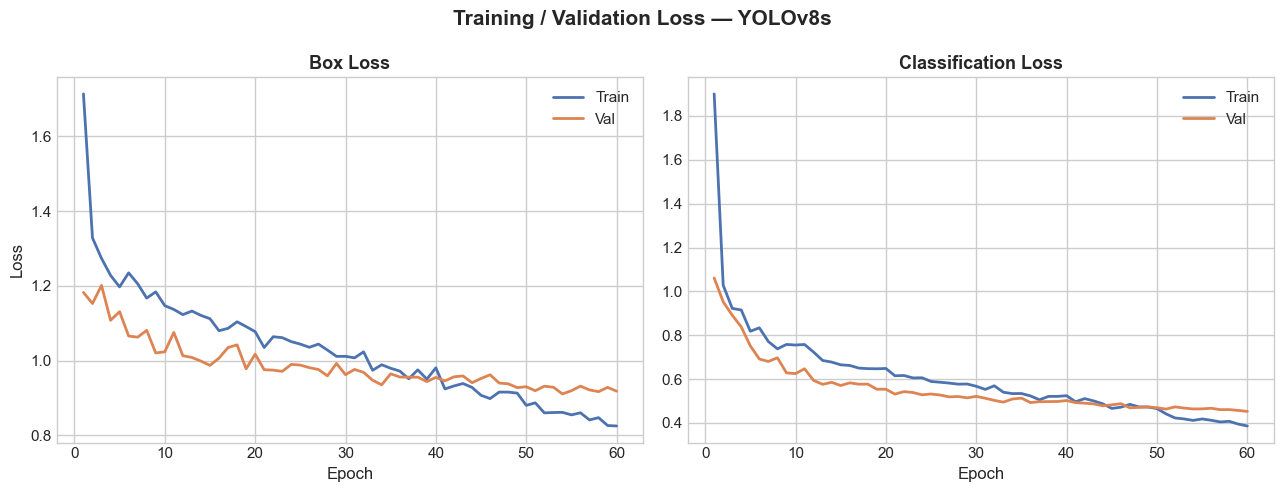

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Point back to the existing training run folder (no retraining needed) ---
PROJECT_ROOT = str(Path.cwd())
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
CHART_DIR = os.path.join(OUTPUT_DIR, "charts")
os.makedirs(CHART_DIR, exist_ok=True)

found = list(Path(OUTPUT_DIR).rglob("results.csv"))
if not found:
    raise FileNotFoundError(f"No results.csv found under {OUTPUT_DIR}")
RUN_DIR = str(max(found, key=lambda p: p.stat().st_mtime).parent)
print(f"Using training results from: {RUN_DIR}")

# --- Load and clean the training log ---
results_df = pd.read_csv(os.path.join(RUN_DIR, "results.csv"))
results_df.columns = [c.strip() for c in results_df.columns]
results_df = (results_df.sort_values('epoch')
              .drop_duplicates(subset='epoch', keep='last')
              .reset_index(drop=True))

# --- Plot the chart ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in [
    (axes[0], 'box_loss', 'Box Loss'),
    (axes[1], 'cls_loss', 'Classification Loss'),
]:
    ax.plot(results_df['epoch'], results_df[f'train/{metric}'], label='Train', linewidth=2)
    ax.plot(results_df['epoch'], results_df[f'val/{metric}'], label='Val', linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.legend()
axes[0].set_ylabel("Loss")

fig.suptitle("Training / Validation Loss — YOLOv8s", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "loss_curve.png"), dpi=200, bbox_inches='tight')
plt.show()

In [12]:
# =====================================================================
# 8. EVALUATION: mAP, IoU, PRECISION, RECALL
# =====================================================================
best_weights_path = os.path.join(RUN_DIR, "weights", "best.pt")
model = YOLO(best_weights_path)  # reload the best model (by validation mAP) for evaluation

map_results = model.val(
    data=DATA_YAML_PATH, imgsz=IMG_SIZE, batch=BATCH_SIZE,
    device=device_str, workers=WORKERS, split="val", plots=False, verbose=True
)

print("\n=== EVALUATION RESULTS ON VALIDATION SET ===")
print(f"mAP@[0.5:0.95] : {map_results.box.map:.4f}")
print(f"mAP@0.50       : {map_results.box.map50:.4f}")
print(f"mAP@0.75       : {map_results.box.map75:.4f}")
print(f"Precision (mp) : {map_results.box.mp:.4f}")
print(f"Recall (mr)    : {map_results.box.mr:.4f}")


Ultralytics YOLOv8.1.0 🚀 Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 168 layers, 11126745 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\FPTSHOP\Desktop\Face_Mask_Detection\data\face-mask-yolo\labels\val.cache... 171 images, 0 backgrounds, 0 corrupt: 100%|██████████| 171/171 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:03<00:00,  7.15it/s]

                   all        171        763      0.929      0.743      0.819      0.572
             with_mask        171        580      0.943      0.912      0.958      0.687
          without_mask        171        156      0.902      0.705        0.8      0.523
 mask_weared_incorrect        171         27      0.943      0.612      0.698      0.508
Speed: 0.4ms preprocess, 5.7ms inference, 0.0ms loss, 1.2ms postprocess per image

=== EVALUATION RESULTS ON VALIDATION SET ===
mAP@[0.5:0.95] : 0.5723
mAP@0.50       : 0.8186
mAP@0.75       : 0.6795
Precision (mp) : 0.9293
Recall (mr)    : 0.7432


In [13]:
# ---------------------------------------------------------------------
# 8.1 Manual IoU + PRECISION/RECALL per class at IoU threshold = 0.5
# (complements the overall mAP above, as required by the assignment: mAP, IoU,
#  Precision, Recall)
# ---------------------------------------------------------------------

def load_yolo_labels(label_path, img_w, img_h):
    """Read a YOLO .txt label file -> pixel boxes (xyxy) + class_id (0-based)."""
    boxes, labels = [], []
    if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
        with open(label_path) as f:
            for line in f:
                cls_id, xc, yc, w, h = map(float, line.split())
                x1 = (xc - w / 2) * img_w
                y1 = (yc - h / 2) * img_h
                x2 = (xc + w / 2) * img_w
                y2 = (yc + h / 2) * img_h
                boxes.append([x1, y1, x2, y2])
                labels.append(int(cls_id))
    boxes_t = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))
    labels_t = torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
    return boxes_t, labels_t


def compute_precision_recall_yolo(model, val_data, images_dir, labels_dir,
                                   class_names, iou_threshold=0.5, conf_threshold=0.25):
    num_classes = len(class_names)
    tp = {c: 0 for c in range(num_classes)}
    fp = {c: 0 for c in range(num_classes)}
    fn = {c: 0 for c in range(num_classes)}

    for item in val_data:
        filename = item['filename']
        img_path = os.path.join(images_dir, filename)
        label_path = os.path.join(labels_dir, os.path.splitext(filename)[0] + ".txt")
        img_w, img_h = item['width'], item['height']

        gt_boxes, gt_labels = load_yolo_labels(label_path, img_w, img_h)

        pred = model.predict(img_path, imgsz=IMG_SIZE, conf=conf_threshold, verbose=False)[0]
        pred_boxes = pred.boxes.xyxy.cpu()
        pred_labels = pred.boxes.cls.cpu().to(torch.int64)

        matched_gt = set()
        if len(pred_boxes) > 0 and len(gt_boxes) > 0:
            ious = torchvision.ops.box_iou(pred_boxes, gt_boxes)
        else:
            ious = torch.zeros((len(pred_boxes), len(gt_boxes)))

        for i in range(len(pred_boxes)):
            cls_pred = int(pred_labels[i])
            if len(gt_boxes) > 0:
                best_iou, best_j = ious[i].max(0)
                best_iou, best_j = float(best_iou), int(best_j)
            else:
                best_iou, best_j = 0.0, -1
            if best_iou >= iou_threshold and best_j not in matched_gt and int(gt_labels[best_j]) == cls_pred:
                tp[cls_pred] += 1
                matched_gt.add(best_j)
            else:
                fp[cls_pred] += 1

        for j in range(len(gt_boxes)):
            if j not in matched_gt:
                fn[int(gt_labels[j])] += 1

    rows = []
    for c in range(num_classes):
        precision = tp[c] / (tp[c] + fp[c]) if (tp[c] + fp[c]) > 0 else 0.0
        recall = tp[c] / (tp[c] + fn[c]) if (tp[c] + fn[c]) > 0 else 0.0
        rows.append({"class": class_names[c], "TP": tp[c], "FP": fp[c], "FN": fn[c],
                      "Precision": round(precision, 4), "Recall": round(recall, 4)})
    return pd.DataFrame(rows)


pr_df = compute_precision_recall_yolo(
    model, val_data, yolo_images_val, yolo_labels_val, YOLO_CLASS_NAMES,
    iou_threshold=0.5, conf_threshold=0.25
)
print("\n=== Precision / Recall per Class (IoU >= 0.5) ===")
print(pr_df.to_string(index=False))



=== Precision / Recall per Class (IoU >= 0.5) ===
                class  TP  FP  FN  Precision  Recall
            with_mask 540  65  40     0.8926  0.9310
         without_mask 117  26  39     0.8182  0.7500
mask_weared_incorrect  16   5  11     0.7619  0.5926


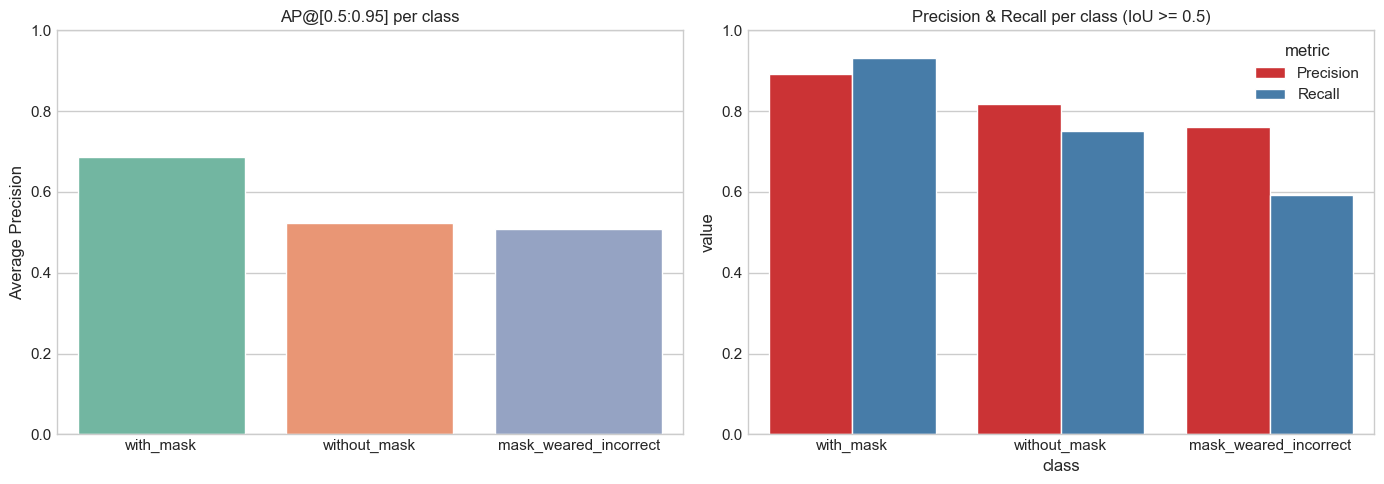

In [14]:
# AP per class + Precision/Recall per class chart (for report/slides)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ap_per_class = list(map_results.box.maps)  # AP@[.5:.95] per class (in YOLO_CLASS_NAMES order)
sns.barplot(x=YOLO_CLASS_NAMES, y=ap_per_class, hue=YOLO_CLASS_NAMES, legend=False,
            ax=axes[0], palette='Set2')
axes[0].set_title("AP@[0.5:0.95] per class")
axes[0].set_ylabel("Average Precision")
axes[0].set_ylim(0, 1)

pr_melt = pr_df.melt(id_vars='class', value_vars=['Precision', 'Recall'], var_name='metric', value_name='value')
sns.barplot(data=pr_melt, x='class', y='value', hue='metric', ax=axes[1], palette='Set1')
axes[1].set_title("Precision & Recall per class (IoU >= 0.5)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "ap_precision_recall_per_class.png"), dpi=150)
plt.show()


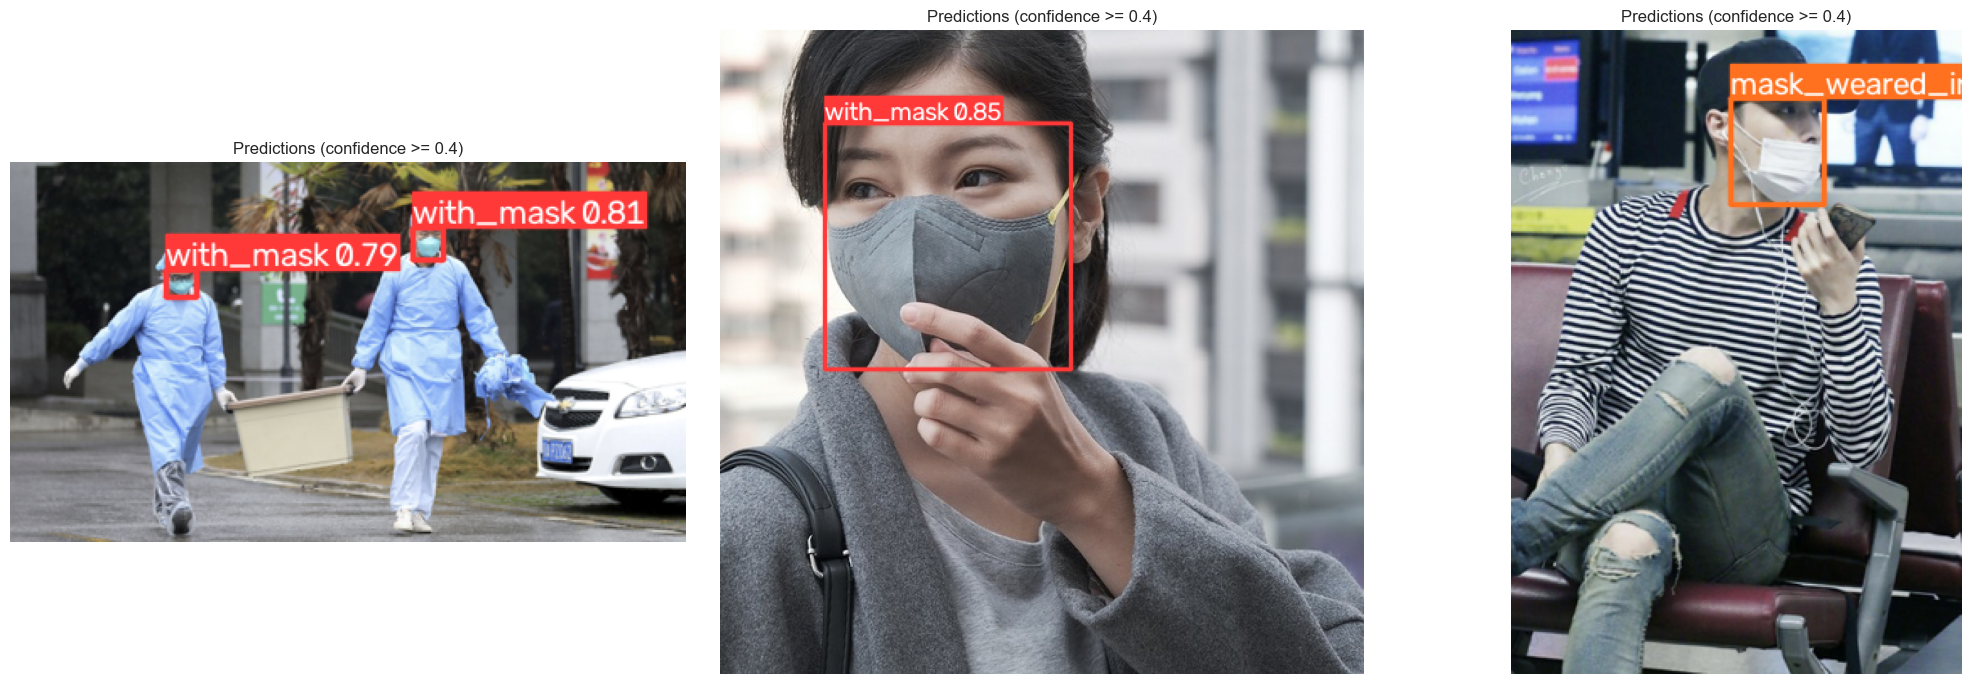

In [15]:
# =====================================================================
# 9. PREDICTION VISUALIZATION ON VALIDATION SAMPLES
# =====================================================================
def visualize_predictions_yolo(model, val_data, images_dir, num_samples=3,
                                conf_threshold=0.4, seed=SEED):
    rng = random.Random(seed)
    samples = rng.sample(val_data, min(num_samples, len(val_data)))

    fig, axes = plt.subplots(1, len(samples), figsize=(7 * len(samples), 7))
    if len(samples) == 1:
        axes = [axes]

    for ax, item in zip(axes, samples):
        img_path = os.path.join(images_dir, item['filename'])
        result = model.predict(img_path, imgsz=IMG_SIZE, conf=conf_threshold, verbose=False)[0]
        annotated = result.plot()  # BGR numpy image with boxes + labels + scores already drawn
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

        ax.imshow(annotated_rgb)
        ax.set_title(f"Predictions (confidence >= {conf_threshold})")
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(CHART_DIR, "sample_predictions.png"), dpi=150)
    plt.show()


visualize_predictions_yolo(model, val_data, yolo_images_val, num_samples=3)


In [16]:
# =====================================================================
# 10. SAVE FINAL MODEL + SUMMARY TABLE (for submission & report/slides)
# =====================================================================
final_model_path = os.path.join(MODEL_DIR, "yolov8s_facemask_best.pt")
shutil.copyfile(best_weights_path, final_model_path)

last_weights_path = os.path.join(RUN_DIR, "weights", "last.pt")
final_last_path = os.path.join(MODEL_DIR, "yolov8s_facemask_last.pt")
if os.path.exists(last_weights_path):
    shutil.copyfile(last_weights_path, final_last_path)

summary = {
    "model": "YOLOv8s (Ultralytics, pretrained COCO)",
    "num_classes": len(YOLO_CLASS_NAMES),
    "img_size": IMG_SIZE,
    "best_lr0": BEST_LR,
    "epochs_trained": NUM_EPOCHS,
    "mAP@[0.5:0.95]": round(float(map_results.box.map), 4),
    "mAP@0.50": round(float(map_results.box.map50), 4),
    "mAP@0.75": round(float(map_results.box.map75), 4),
    "Precision": round(float(map_results.box.mp), 4),
    "Recall": round(float(map_results.box.mr), 4),
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(OUTPUT_DIR, "results_summary.csv"), index=False)

print("Saved:")
print(f"  - Best model (by validation mAP)   : {final_model_path}")
print(f"  - Final model (last epoch)          : {final_last_path}")
print(f"  - Charts (loss/mAP/PR/predictions)  : {CHART_DIR}")
print(f"  - Summary table (CSV)               : {os.path.join(OUTPUT_DIR, 'results_summary.csv')}")
print("\n=== FINAL RESULTS SUMMARY ===")
print(summary_df.to_string(index=False))


Saved:
  - Best model (by validation mAP)   : c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\models\yolov8s_facemask_best.pt
  - Final model (last epoch)          : c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\models\yolov8s_facemask_last.pt
  - Charts (loss/mAP/PR/predictions)  : c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\charts
  - Summary table (CSV)               : c:\Users\FPTSHOP\Desktop\Face_Mask_Detection\outputs\results_summary.csv

=== FINAL RESULTS SUMMARY ===
                                 model  num_classes  img_size  best_lr0  epochs_trained  mAP@[0.5:0.95]  mAP@0.50  mAP@0.75  Precision  Recall
YOLOv8s (Ultralytics, pretrained COCO)            3       416     0.005              60          0.5723    0.8186    0.6795     0.9293  0.7432


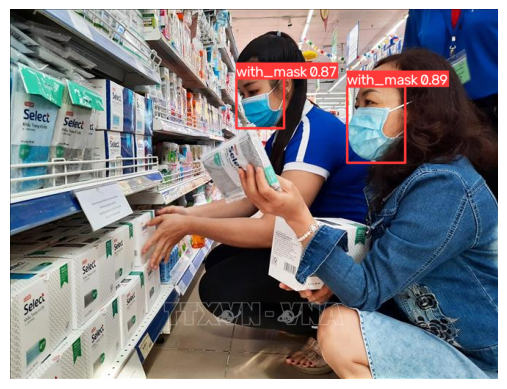

with_mask: 0.89
with_mask: 0.87


In [17]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("outputs/models/yolov8s_facemask_best.pt")

# Paste your image path here
IMAGE_PATH = r"C:\Users\FPTSHOP\Downloads\khau-trang(1).jpg"

# Run detection
result = model.predict(IMAGE_PATH, conf=0.4, verbose=False)[0]

# Show image with boxes drawn
annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
plt.imshow(annotated)
plt.axis('off')
plt.show()

# Print detected objects
for box in result.boxes:
    cls_name = model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    print(f"{cls_name}: {conf:.2f}")